<a href="https://colab.research.google.com/github/redinbluesky/nlp-with-transformers/blob/main/09-레이블_부족_문제_다루기.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  목차
* [Chapter 0 개요](#chapter0)
* [Chapter 1 깃허브 이슈 태거 만들기](#chapter1)
    * [Chapter 1-1 데이터 다운로드하기](#chapter1-1)
    * [Chapter 1-2 데이터 준비하기](#chapter1-2)
    * [Chapter 1-3 훈련 세트 만들기](#chapter1-3)
    * [Chapter 1-4 훈련 슬라이스 만들기](#chapter1-4)
* [Chapter 2 나이브 베이즈 모델 만들기](#chapter2)    
* [Chapter 3 레이블링된 데이터가 없는 경우](#chapter3)    

## Chapter 0 개요 <a class="anchor" id="chapter0"></a>
1. 레이블링된 데이터의 비율에 따라 적절한 방법을 선택하는 과정은 아래의 이미지와 같다.

    ![레이블링된 데이터 비율에 따른 방법 선택](image/09-01-choose_options.png)

2. 이 결정과정을 따라서 자라나 깃허브 같은 이슈 트래커의 고객지원 팀이 마주하는 공통적인 문제를 이장에서 해결한다.
    - 이슈 내용을 기반으로 메타데이터에 태그를 추가한다.
    - 태그는 이슈 종류, 문제를 일으키는 제품, 이슈를 처리하는 팀 등이 된다.
    - 이 과정을 자동화하여 생산선을 높인다.

## Chapter 1 깃허브 이슈 태거 만들기 <a class="anchor" id="chapter1"></a>
1. 트랜스포머스 저정소의 이슈 탭을 보면 아래와 같은 화면을 볼 수 있다.
    - 이슈는 제목, 설명, 이슈의 태그등을 담고 있어 자연스렙게 지도 학습 작업을 구성할 수 있다.
    - 이슈의 제목과 설명이 주어지면 한 개 이상의 레이블을 예측하는 방식이다.
    - 이슈에 여러 개의 레이블을 할당할 수 있으므로 다중 레이블 텍스트 분류 문제로 다룬다.

        ![트랜스포머스 이슈 탭](image/09-02-transformers_issues.png)

### Chapter 1-1 데이터 다운로드하기 <a class="anchor" id="chapter1-1"></a>
1. 저장소의 이슈를 모두 다운로드하려면 깃허브 REST API에 있는 Issue 엔드포인트를 반복해서 호출해야한다.
    - JSON 형식으로 응답하며, 이슈 상태, 생성자, 제목, 본문, 레이블 등 다양한 이슈에 관한 정보를 포함한다.

2. 모든 이슈를 다운로드하려면 시간이 걸리므로 미리 다운로드한 데이터를 사용한다.
    - data/github-issues-transformers.jsonl 파일을 사용한다.

### Chapter 1-2 데이터 준비하기 <a class="anchor" id="chapter1-2"></a>

In [99]:
# 다운로드한 이슈 JSONL 파일을 판다스 데이터프레임으로 로드한다.
import pandas as pd

df_issues = pd.read_json("data/github-issues-transformers.jsonl", lines=True)
print(f"데이터프레임 크기: {df_issues.shape}")

데이터프레임 크기: (9930, 26)


In [100]:
print(df_issues.loc[2])

url                         https://api.github.com/repos/huggingface/trans...
repository_url              https://api.github.com/repos/huggingface/trans...
labels_url                  https://api.github.com/repos/huggingface/trans...
comments_url                https://api.github.com/repos/huggingface/trans...
events_url                  https://api.github.com/repos/huggingface/trans...
html_url                    https://github.com/huggingface/transformers/is...
id                                                                  849529761
node_id                                              MDU6SXNzdWU4NDk1Mjk3NjE=
number                                                                  11044
title                       [DeepSpeed] ZeRO stage 3 integration: getting ...
user                        {'login': 'stas00', 'id': 10676103, 'node_id':...
labels                      [{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj...
state                                                           

1. 데이터셋에는 거의 10,000개의 이슈가 있다.
    - 각 행에는 URL, ID, 날짜, 사용자, 제목, 본문, 레이블 같은 필드들이 있다.

In [101]:
# 중요 정보 샘플 출력
cols = ["url","id","title","user","labels","state","created_at", "body"]
df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,"[{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj..."
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [102]:
# labels 정보 출력
df_issues.loc[2, "labels"]

[{'id': 2659267025,
  'node_id': 'MDU6TGFiZWwyNjU5MjY3MDI1',
  'url': 'https://api.github.com/repos/huggingface/transformers/labels/DeepSpeed',
  'name': 'DeepSpeed',
  'color': '4D34F7',
  'default': False,
  'description': ''}]

In [103]:
# 이슈중 분류로 사용할 name 필드를 labels 이름으로 덥는다.
#   - labels의 각 행은 깃허브 레이블의 리스트가 된다.
df_issues["labels"] = df_issues["labels"].apply(lambda x: [meta["name"] for meta in x])
df_issues["labels"].head() 
df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,[DeepSpeed]
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [104]:
# labels 0-4 출력
df_issues["labels"].head().to_frame()

,labels
0,[]
1,[]
2,[DeepSpeed]
3,[]
4,[]


In [105]:
# 각 행의 길이를 계산해 이슈에 할당된 레이블의 개수를 센다.
#   - 대부분의 이슈는 레이블이 없거나 하나이고, 그 이상 있는 이슈는 적다
df_issues["labels"].apply(lambda x: len(x)).value_counts().to_frame().T

labels,0,1,2,3,4,5
count,6440,3057,305,100,25,3


In [106]:
# 데이터셋에서 가장 만이 등장한 상위 8개의 레이블을 출력한다.
#   - 판다스의 explode 메서드를 사용해 리스트를 개별 항목으로 분리한 후 value_counts로 빈도수를 센다.
df_counts = df_issues["labels"].explode().value_counts()
print(f"레이블 개수: {len(df_counts)}")
df_counts.head(8).to_frame().T

레이블 개수: 65


labels,wontfix,model card,Core: Tokenization,New model,Core: Modeling,Help wanted,Good First Issue,Usage
count,2284,649,106,98,64,52,50,46


2. 데이터셋에 고유한 레이블이 65개 있고, 비율이 매우 불균형하다.
    - Good Fist Issue나 Help Wanted 같은 설명만으로 예측이 어려운 레이블에 대한 태거를 만드는데 초점을 둔다.

In [107]:
# 데이터셋을 필터링해 다룰 레입르만 남긴다.
#   - 레이블을 읽기 쉽게 변환한다.
label_map = {"Core: Tokenization": "tokenization",
             "New model": "new model",
             "Core: Modeling": "model training",
             "Usage": "usage",
             "Core: Pipeline": "pipeline",
             "TensorFlow": "tensorflow or tf",
             "PyTorch": "pytorch",
             "Examples": "examples",
             "Documentation": "documentation"}

def filter_labels(x):
    return [label_map[label] for label in x if label in label_map]

df_issues["labels"] = df_issues["labels"].apply(filter_labels)
all_labels = list(label_map.values())
print(all_labels)
print(df_issues["labels"].head().to_frame()) 

['tokenization', 'new model', 'model training', 'usage', 'pipeline', 'tensorflow or tf', 'pytorch', 'examples', 'documentation']
  labels
0     []
1     []
2     []
3     []
4     []


In [108]:
# 새로운 레이블에 대한 분포를 확인한다.
df_counts = df_issues["labels"].explode().value_counts()
df_counts.to_frame().T

labels,tokenization,new model,model training,usage,pipeline,tensorflow or tf,pytorch,documentation,examples
count,106,98,64,46,42,41,37,28,24


In [109]:
# 이슈에 레이블이 있는지 없는지를 나타내는 열을 만든다.
df_issues["split"] = "unlabeled"
mask = df_issues["labels"].apply(lambda x: len(x) > 0)
df_issues.loc[mask, "split"] = "labeled"
df_issues["split"].value_counts().to_frame().T

split,unlabeled,labeled
count,9489,441


In [110]:
# 샘플 하나를 확인한다.
#   - 새로운 모델 구조를 제안하기 때문에 "new model" 레이블이 붙어 있다.
for column in ["title", "body", "labels", "split"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

title: Add new CANINE model

body: # 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less brittle than manually en

labels: ['new model']

split: labeled



In [111]:
# 타이틀에 있는 정보가 분류에 유용하므로 바디와 합친다.
df_issues["text"] = (df_issues.apply(lambda x: x["title"] + "\n\n" + x["body"], axis=1))

# 샘플 하나를 확인한다.
for column in ["text", "labels", "split"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

text: Add new CANINE model

# 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less br

labels: ['new model']

split: labeled



In [112]:
df_issues["text"] = (df_issues
                     .apply(lambda x: x["title"] + "\n\n" + x["body"], axis=1))

In [113]:
# drop_duplicates 메서드를 사용해 중복 샘플을 제거한다.
len_before = len(df_issues)
df_issues = df_issues.drop_duplicates(subset=["text"])
print(f"삭제된 중복 이슈 %: {(len_before - len(df_issues)) / len_before * 100:.2f}%")

삭제된 중복 이슈 %: 1.88%


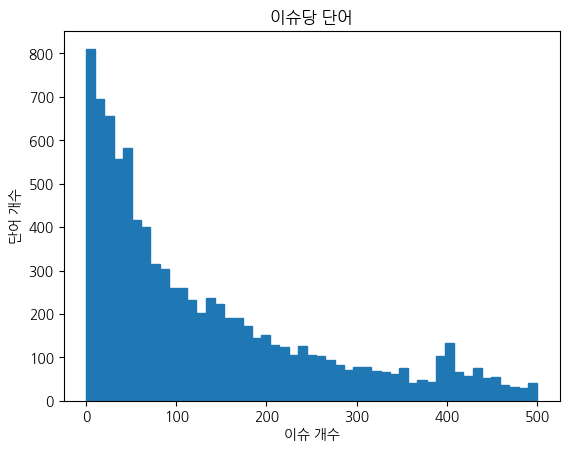

In [114]:
# 모델의 문맥 크기로 자르기 전 텍스트의 단어 개수 분포를 확인한다.
import matplotlib.pyplot as plt
import numpy as np

# 나눔고딕 폰트 적용
plt.rc('font', family='NanumGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


(df_issues["text"].str.split().apply(len).hist(bins=np.linspace(0, 500, 50), grid=False, edgecolor='C0'))
plt.title("이슈당 단어")
plt.xlabel("이슈 개수")
plt.ylabel("단어 개수")
plt.show()

3. 코드를 함께 포스팅하는 경우 보통 이슈의 길이가 커진다.
    - 대부분의 트랜스포머 모델의 문캑의 크기는 512개의 토큰이나 그 이상이기 때문에 일부 긴 이슈르 잘라내도 무방한다.

### Chapter 1-3 훈련 세트 만들기     <a class="anchor" id="chapter1-3"></a>
1. 다중 레이블 문제에서는 훈련 세트와 검증 세트를 만드는 것이 조금 까다롭다.
    - 모든 레이블에 대해 균형잡힌 비율을 보장하지 못하기 때문이다.
    - scikit-multilearn 라이브러리를 사용하면 도움이 된다.

In [115]:
# MultiLableBinarizer를 사용해 pytorch와 tokenization 같은 레이블 모델을 처리가은한 형식으로 변환한다.
#   - 레이블 이름의 리스트를 받고 레이블에 해당하는 위치는 1, 나머지는 0인 벡터를 반환한다.
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
mlb.fit([all_labels])
mlb.transform([["tokenization", "new model"], ["pytorch"]])

array([[0, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [116]:
print(mlb.classes_)

['documentation' 'examples' 'model training' 'new model' 'pipeline'
 'pytorch' 'tensorflow or tf' 'tokenization' 'usage']


2. 첫 번째 행은 2 개의 1을 포함하는데, 각각 new model과 tokenization 레이블에 해당한다.
    - 두 번째 행은 1 개의 1을 포함하는데, pytorch 레이블에 해당한다.

In [117]:
# scikit-multilearn의 iterative_train_test_split 메서드를 사용해 다중 레이블 훈련 세트와 검증 세트를 만든다.
#   - 레이블의 균형을 잡기 위해 반복적으로 훈련/테스트 세트를 만든다.
from skmultilearn.model_selection import iterative_train_test_split

def balanced_split(df, test_size=0.5):
    ind = np.expand_dims(np.arange(len(df)), axis=1)
    labels = mlb.transform(df["labels"])
    ind_train, _, ind_test, _ = iterative_train_test_split(ind, labels,
                                                           test_size)
    return df.iloc[ind_train[:, 0]], df.iloc[ind_test[:,0]]

In [118]:
from sklearn.model_selection import train_test_split

df_clean = df_issues[["text", "labels", "split"]].reset_index(drop=True).copy()
print(f"df_clean 데이터 크기: {len(df_clean)}")

df_unsup = df_clean.loc[df_clean["split"] == "unlabeled", ["text", "labels"]]
print(f"df_unsup 데이터 크기: {len(df_unsup)}")

df_sup = df_clean.loc[df_clean["split"] == "labeled", ["text", "labels"]]
print(f"df_sup 데이터 크기: {len(df_sup)}")

np.random.seed(0)
df_train, df_tmp = balanced_split(df_sup, test_size=0.5)
df_valid, df_test = balanced_split(df_tmp, test_size=0.5)

print(f"훈련 세트 크기: {len(df_train)}")

df_clean 데이터 크기: 9743
df_unsup 데이터 크기: 9303
df_sup 데이터 크기: 440
훈련 세트 크기: 223


In [147]:
from datasets import Dataset, DatasetDict

ds = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),
    "valid": Dataset.from_pandas(df_valid.reset_index(drop=True)),
    "test": Dataset.from_pandas(df_test.reset_index(drop=True)),
    "unsup": Dataset.from_pandas(df_unsup.reset_index(drop=True))})

### Chapter 1-4 훈련 슬라이스 만들기     <a class="anchor" id="chapter1-4"></a>
1. 희소하게 레이블링된 데이터와 다중 레이블 분류에 대해 알아본다.

2. 적은 양의 레이블링된 데이터에서 얼마나 좋은 성능을 내는지 확인하기 위해 훈련 데이터의 슬라이스를 만든다.

In [120]:
np.random.seed(0)
all_indices = np.expand_dims(list(range(len(ds["train"]))), axis=1)
indices_pool = all_indices
labels = mlb.transform(ds["train"]["labels"])
train_samples = [8, 16, 32, 64, 128]
train_slices, last_k = [], 0

for i, k in enumerate(train_samples):
    # 다음 슬라이스 크기를 채우는데 필요한 샘플을 분할합니다
    indices_pool, labels, new_slice, _ = iterative_train_test_split(
        indices_pool, labels, (k-last_k)/len(labels))
    last_k = k
    if i==0: train_slices.append(new_slice)
    else: train_slices.append(np.concatenate((train_slices[-1], new_slice)))

# 마지막 슬라이스를 포함하면 코랩의 경우 메모리 부족이 발생합니다.
# 대신 코랩 프로(https://colab.research.google.com/signup)를 사용하세요.
# 코랩을 사용하려면 다음 라인을 주석 처리하세요.
train_slices.append(all_indices), train_samples.append(len(ds["train"]))

train_slices = [np.squeeze(train_slice) for train_slice in train_slices]

In [121]:
print("목표 분할 크기:")
print(train_samples)
print("실제 분할 크기:")
print([len(x) for x in train_slices])

목표 분할 크기:
[8, 16, 32, 64, 128, 223]
실제 분할 크기:
[10, 19, 36, 68, 134, 223]


## Chapter 2 나이브 베이즈 모델 만들기     <a class="anchor" id="chapter2"></a>
1. 새로운 NLP 프로젝트를 시작할 때마다 강력한 기준 모델을 구현하는 것은 좋은 습관이다.
    - 복잡한 모델을 탐색할 때 기준 모델이 간단한 검증 역활을 한다.
    - 예를 들어 BERT-large 모델을 훈련하고 검증 세트에서 80%의 정확도를 얻었다고 가정하자
    - 기준 모델이 나이브 베이즈 분류기로 85%의 정확도를 얻었다면 BERT-large 모델을 다시 살펴봐야 한다.

2. 나이브 베이즈 분류기
    - 간단하고 훈련 속도가 빠르며 입력의 변동에 매우 안정적이다.
    - 나이브 베이즈 구현은 다중 레이블 분류를 지원하지 않는다.
    - scikit-multilearn 라이브러리를 사용하여 이를 OvR 분류작업으로 변경한다.
    

In [122]:
# MultiLabelBinarizer를 사용해 레이블을 이진 벡터로 변환하는 함수를 만든다.
def prepare_labels(batch):
    batch["label_ids"] = mlb.transform(batch["labels"])
    return batch

ds = ds.map(prepare_labels, batched=True)
print(ds["train"][0])

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/9303 [00:00<?, ? examples/s]

{'text': "Add new CANINE model\n\n# 🌟 New model addition\r\n\r\n## Model description\r\n\r\nGoogle recently proposed a new **C**haracter **A**rchitecture with **N**o tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the title is exciting:\r\n\r\n> Pipelined NLP systems have largely been superseded by end-to-end neural modeling, yet nearly all commonly-used models still require an explicit tokenization step. While recent tokenization approaches based on data-derived subword lexicons are less brittle than manually engineered tokenizers, these techniques are not equally suited to all languages, and the use of any fixed vocabulary may limit a model's ability to adapt. In this paper, we present CANINE, a neural encoder that operates directly on character sequences, without explicit tokenization or vocabulary, and a pre-training strategy that operates either directly on characters or optionally uses subwords as a soft inductive bias. To use its finer-grained input e

In [123]:
# 분류기의  성능을 평가하기 위해 마이크로와 매크로 F1 점수를 사용한다.
#   - macro_scores: 자주 등장하는 레이블에 대한 성능 추적
#   - micro_scores: 빈도를 무시하고 모든 레이블에 대한 성추적
from collections import defaultdict

macro_scores, micro_scores = defaultdict(list), defaultdict(list)

In [124]:
# 모델을 훈련하고 훈련 세트 크기를 증가시키면서 성능을 평가한다.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.feature_extraction.text import CountVectorizer

for train_slice in train_slices:
    # 훈련 슬라이스와 테스트 데이터를 준비합니다
    ds_train_sample = ds["train"].select(train_slice)
    y_train = np.array(ds_train_sample["label_ids"])
    y_test = np.array(ds["test"]["label_ids"])
    # 간단한 CountVectorizer를 사용해 텍스트를 토큰 카운트로 인코딩합니다
    count_vect = CountVectorizer()
    X_train_counts = count_vect.fit_transform(ds_train_sample["text"])
    X_test_counts = count_vect.transform(ds["test"]["text"])
    # 모델을 만들고 훈련합니다!
    classifier = BinaryRelevance(classifier=MultinomialNB())
    classifier.fit(X_train_counts, y_train)
    # 예측을 생성하고 평가합니다
    y_pred_test = classifier.predict(X_test_counts)
    clf_report = classification_report(
        y_test, y_pred_test, target_names=mlb.classes_, zero_division=0,
        output_dict=True)
    # 평가 결과를 저장합니다
    macro_scores["Naive Bayes"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Naive Bayes"].append(clf_report["micro avg"]["f1-score"])

In [125]:
import matplotlib.pyplot as plt

def plot_metrics(micro_scores, macro_scores, sample_sizes, current_model):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for run in micro_scores.keys():
        if run == current_model:
            ax0.plot(sample_sizes, micro_scores[run], label=run, linewidth=2)
            ax1.plot(sample_sizes, macro_scores[run], label=run, linewidth=2)
        else:
            ax0.plot(sample_sizes, micro_scores[run], label=run,
                     linestyle="dashed")
            ax1.plot(sample_sizes, macro_scores[run], label=run,
                     linestyle="dashed")

    ax0.set_title("Micro F1 scores")
    ax1.set_title("Macro F1 scores")
    ax0.set_ylabel("Test set F1 score")
    ax0.legend(loc="lower right")
    for ax in [ax0, ax1]:
        ax.set_xlabel("Number of training samples")
        ax.set_xscale("log")
        ax.set_xticks(sample_sizes)
        ax.set_xticklabels(sample_sizes)
        ax.minorticks_off()
    plt.tight_layout()
    plt.show()

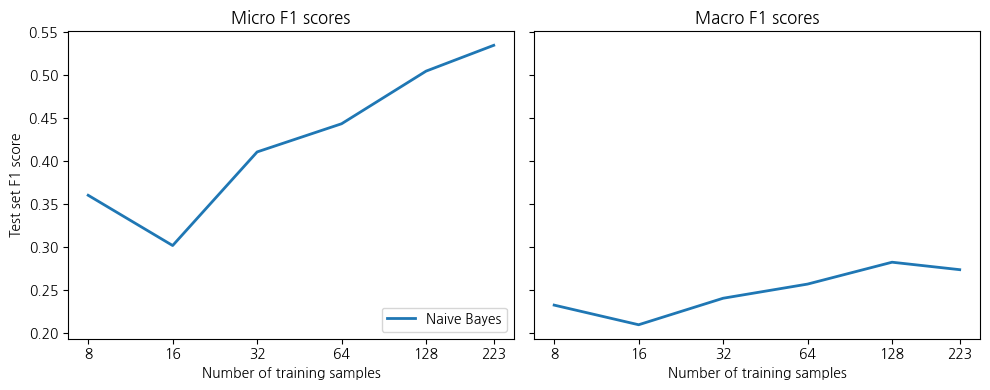

In [126]:
plot_metrics(micro_scores, macro_scores, train_samples, "Naive Bayes")

3.  첫 번째 그래프는 샘플 개수를 로그 스케일로 표현했다.
    - 훈련 샘플 개수의 증가에 따라 마이크로와 캐크로 F1 점수가 모두 증가하는 것을 볼 수 있다.

## Chapter 3 레이블링된 데이터가 없는 경우        <a class="anchor" id="chapter3"></a>
1. 레이블이 있는 과거 데이터가 없거나, 데이터에 대한 레이블을 구하기 어려운 경우 제로샷 분류를 사용할 수 있다.
    - 작업별 말뭉치에서 추가로 미세 튜닝하지 않고 사전 훈련된 모델을 사용하는 것이 목표다.


2. 다음과 같은 문장을 제공해 모델이 문서를 분류하게끔 트릴을 쓸 수 있다.
    - "This section was about the topic [MASK]"
    - 이런 문장을 데이터셋에 등장하는 자연스러운 텍스트 이므로 모델은 문서의 주제를 합리적으로 예측해야한다.

3. 한 아이는 자동차 영화를 좋아하고 한 아이드는 동물 영화를 좋아한다.
    - 개봉된 영화를 보고 새 영화의 주제가 어떤 것인지 알려주는 함수를 만들려고한다.

In [127]:
# 마스크드 언어 모델을 사용해 마스킹된 토큰 내용을 예측하는 fill-mask 파이프라인에 BERT 베이스 모델을 로드한다.
from transformers import pipeline

pipe = pipeline("fill-mask", model="bert-base-uncased")

2026-02-11 14:54:02.392556: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-11 14:54:02.889777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-11 14:54:04.366057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-11 14:54:04.368579: I external/local_xla/xla/tsl/cu

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cuda:0


In [129]:
# 약간 영화 설명을 작성하고 마스킹된 단어를 위한 프롬프트를 추가한다.
#   - 프롬프트는 모델이 분류하도록 안내하는 역할을 한다.
#   - fill-mask 파이프라인은 마스킹된 위치에 놓기에 가장 가능성이 높은 단어를 예측한다.
movie_desc = "The main characters of the movie madacascar are a lion, a zebra, a giraffe, and a hippo."
prompt = "The movie is about [MASK]."

output = pipe(movie_desc + " " + prompt)
for element in output:
    print(f"토큰 {element['token_str']}: \t 점수 {element['score']:.3f}%")

토큰 animals: 	 점수 0.103%
토큰 lions: 	 점수 0.066%
토큰 birds: 	 점수 0.025%
토큰 love: 	 점수 0.015%
토큰 hunting: 	 점수 0.013%


In [130]:
# 가장 높은 토큰을 얻는 대신 주어진 토큰에 대한 확률도 출력하도록 수정한다.
#   - cars, animals를 선택해 타깃으로 파이프라인에 전달한다.
output = pipe(movie_desc + " " + prompt, targets=["cars", "animals"])
for element in output:
    print(f"토큰 {element['token_str']}: \t 점수 {element['score']:.3f}%")

토큰 animals: 	 점수 0.103%
토큰 cars: 	 점수 0.001%


In [131]:
# 자돋차에대한 설명에서도 잘 작동하는지 확인한다.
movie_desc = "In the movie transformers aliens can morph into a wide raange of vehicles."

output = pipe(movie_desc + " " + prompt, targets=["cars", "animals"])
for element in output:
    print(f"토큰 {element['token_str']}: \t 점수 {element['score']:.3f}%")

토큰 cars: 	 점수 0.107%
토큰 animals: 	 점수 0.005%


4. 위의 예제는 사전 훈련된 모델을 추가 훈련 없이 다른 작업에 적용하는 방법을 보여준다.
    - 이 접근법은 레이블링된 데이터가 거의 없거나 전혀 없는 상황에서 유용하다.

5. 자연어추론(NLI)에서 미세 튜닝된 모델을 적용하면 결과가 더 좋은지 확인한다.
    - 텍스트함의는 모델이 두 개의 텍스트 구절이 서로 연결되는지 아니면 모순되는지 판단한다.
    - 일반적으로 모델은 NLNI 말뭉치나, XNLI 말뭉치 같은 데이터셋에서 함의와 모순믈 감지하도록 훈련된다.

6. 텍스트가 참일 때 entailment 레이블을 사용하고, 거짓일 때 contradiction 레이블을 사용한다.
    - 두 경우에 해당하지 않는 경우에는 neutral 레이블을 사용한다.
    
        ![제로샷 분류를 위한 자연어 추론 모델](image/09-03-zero_shot_nli.png)

7. MNLI 데이터셋에서 훈련한 모델을 사용하여 어떤 레이블도 필요하지 않은 분류기를 만들 수 있다.
    - 분류하고자 하는 텍스트를 전제로 사용해 다음과 같은 가설을 만든다.
    - "This example is about {label}."
        - {label}에는 클래스 이름을 넣는다.
    - 함의 점수는 전체가 주제와 얼마나 관련되는지 알려준다.
    - 이 방식은 정방향 패스를 실행하므로 일반적인 분류기보다 덜 효율적이다.
    - 레이블 이름 선택이 정확도에 큰 영향을 미치므로 의미있는 이름을 선택하는 것이 좋다.

In [132]:
# 트랜스포머스에 내장된 MNLI 모델을 사용한다.
from transformers import pipeline

pipe = pipeline("zero-shot-classification", device=0)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [134]:
# 레이블 이름과 함께 파이프라인데 전달
#   - multi_label=True로 설정해 모든 점수가 반환되도록 한다.
#   - 단일 레이블 분류의 합은 1이 지만, 다중 레이블 분류의 합은 1이 넘을 수 있다.
sample = ds["test"][0]
print(f"레이블: {sample['labels']}")
output = pipe(sample["text"], all_labels, multi_label=True)
print(output["sequence"][:400])
print("\예측: ")

for label, score in zip(output["labels"], output["scores"]):
    print(f"레이블 {label}: \t 점수 {score:.3f}%")

레이블: ['new model']
Add GPT-Neo

# 🌟 New model addition

Please add GPT-Neo

## Model description

> GPT-Neo is the code name for a series of transformer-based language models loosely styled around the GPT architecture that Eleuther AI plans to train and open source. Eleuther AI's primary goal is to replicate a GPT-3 sized model and open source it to the public, for free.

<!-- Important information -->

##
\예측: 
레이블 new model: 	 점수 0.998%
레이블 model training: 	 점수 0.753%
레이블 documentation: 	 점수 0.593%
레이블 pipeline: 	 점수 0.491%
레이블 tensorflow or tf: 	 점수 0.361%
레이블 usage: 	 점수 0.311%
레이블 examples: 	 점수 0.286%
레이블 pytorch: 	 점수 0.277%
레이블 tokenization: 	 점수 0.218%


8. 모델은 텍스트의 주제가 "new model"이라고 강하게 확신한다(0.998%).
    - 다른 레이블에도 비교적 높은 점수를 할당한다.

9. MNLI 데이터셋에 있는 텍스트와 모델이 학습한 도메인이 달라 모델이 판단하기 어렵다.
    - 훈련 데이터와 얼마나 비슷한지에 따라 특정 도메인에서 더 잘 수행되기도 한다.

In [150]:
# 제로샷 파이프라인에 하나의 샘플을 주입하는 함수를 작성하고 map() 메서드로 전체 검증 세트에 적용한다.
def zero_shot_pipeline(example):
    output = pipe(example["text"], all_labels, multi_label=True)
    example["predicted_labels"] = output["labels"]
    example["predicted_scores"] = output["scores"]
    return example

ds_zero_shot = ds["valid"].map(zero_shot_pipeline)

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

In [151]:
# 샘플마다 임곗값을 초과한 모든 레이블을 선택 할지 상위 k개의 레이블을 선택할지 결정한다.
def get_preds(example, threshold=None, top_k=None):
    preds = []
    if threshold:
        for label, score in zip(example["predicted_labels"],
                                example["predicted_scores"]):
            if score >= threshold:
                preds.append(label)
    elif top_k:
        for i in range(top_k):
            preds.append(example["predicted_labels"][i])
    else:
        raise ValueError("threshold or top_k must be set")
    return {"pred_label_ids": list(np.squeeze(mlb.transform([preds])))}

In [152]:
# 레이블을 사용해 사이킷런의 분류 리포트 결과를 반환하는 두 번째 함수 get_clf_report를 작성한다.
def get_clf_report(ds):
    y_true = np.array(ds["label_ids"])
    y_pred = np.array(ds["pred_label_ids"])
    clf_report = classification_report(
        y_true, y_pred, target_names=mlb.classes_, zero_division=0,
        output_dict=True)
    return clf_report

In [153]:
# k를 증가시키면서 탑-k 방법을 적용 후 그래프를 그린다.
macros, micros = [], []
topks = [1, 2, 3, 4]
for topk in topks:
    ds_zero_shot = ds_zero_shot.map(get_preds, batched=False,
                                    fn_kwargs={"top_k": topk})
    clf_report = get_clf_report(ds_zero_shot)
    macros.append(clf_report["macro avg"]["f1-score"])
    micros.append(clf_report["micro avg"]["f1-score"])
plt.plot(topks, macros, label="매크로 F1")
plt.plot(topks, micros, label="마이크로 F1")
plt.xlabel("Top k labels")
plt.ylabel("F1 score")
plt.legend(loc='best')
plt.title("제로샷 분류기 성능")
plt.show()


Map:   0%|          | 0/106 [00:00<?, ? examples/s]

ValueError: Column 'label_ids' doesn't exist.

10. "탑-1"을 선택하는 방식이 최상의 결과를 냈다.

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Text(0.5, 1.0, '제로샷 분류기 성능')

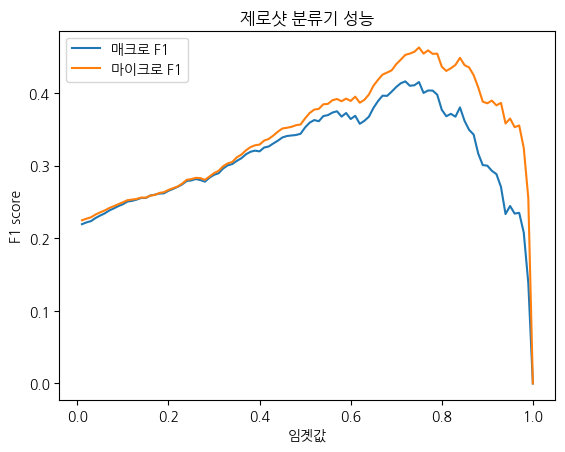

In [140]:
# 임곗값 방식과 비교한다.
macros, micros = [], []
thresholds = np.linspace(0.01, 1, 100)
for threshold in thresholds:
    ds_zero_shot = ds_zero_shot.map(get_preds, batched=False,
                                    fn_kwargs={"threshold": threshold})
    clf_report = get_clf_report(ds_zero_shot)
    macros.append(clf_report["macro avg"]["f1-score"])
    micros.append(clf_report["micro avg"]["f1-score"])
plt.plot(thresholds, macros, label="매크로 F1")
plt.plot(thresholds, micros, label="마이크로 F1")
plt.xlabel("임곗값")
plt.ylabel("F1 score")
plt.legend(loc='best')
plt.title("제로샷 분류기 성능")

In [142]:
best_t, best_micro = thresholds[np.argmax(micros)], max(micros)
print(f"최적 임곗값: {best_t:.2f}에서 마이크로 F1 점수: {best_micro:.3f}")
best_t, best_macro = thresholds[np.argmax(macros)], max(macros)
print(f"최적 임곗값: {best_t:.2f}에서 매크로 F1 점수: {best_macro:.3f}")

최적 임곗값: 0.75에서 마이크로 F1 점수: 0.463
최적 임곗값: 0.72에서 매크로 F1 점수: 0.416


In [148]:
# 테스트 세트에서 제로샷 분류와 나이브 베이즈를 비교한다.
ds_zero_shot = ds['test'].map(zero_shot_pipeline)

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

In [149]:
ds_zero_shot = ds_zero_shot.map(get_preds, fn_kwargs={'topk': 1})
clf_report = get_clf_report(ds_zero_shot)
for train_slice in train_slices:
    macro_scores['Zero Shot'].append(clf_report['macro avg']['f1-score'])
    micro_scores['Zero Shot'].append(clf_report['micro avg']['f1-score'])

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

TypeError: get_preds() got an unexpected keyword argument 'topk'. Did you mean 'top_k'?